## Topics

- Explain Bag-of-Words, binary feature presence, and TF-IDF.
- Run four supervised learning tasks with common classifiers.
- Use k-means and hierarchical clustering for exploratory questions.

## Setup

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn scipy nltk sentence-transformers

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram

RANDOM_STATE = 42

## Creating  Dummy Data

Here, each row is one short document.

We include several labels so we can invent different supervised tasks:

- `category`: topic label such as sports, technology, politics, entertainment, or mixed.
- `sentiment`: positive or negative.

In [4]:
documents = [
    ("The team won the final game with a brilliant goal", "sports", "positive"),
    ("The coach praised the players after the exciting match", "sports", "positive"),
    ("The striker missed an easy chance and fans were angry", "sports", "negative"),
    ("The tournament schedule was slow and confusing", "sports", "negative"),
    ("A calm training session helped the team prepare", "sports", "positive"),

    ("The new phone has a bright screen and fast battery", "technology", "positive"),
    ("The laptop update fixed the annoying software bug", "technology", "positive"),
    ("The app crashed again and lost my files", "technology", "negative"),
    ("The camera quality is poor in dark rooms", "technology", "negative"),
    ("The robot assistant answered questions quickly", "technology", "positive"),

    ("The mayor announced a hopeful climate policy", "politics", "positive"),
    ("The debate became tense after the budget question", "politics", "negative"),
    ("Voters praised the clear speech about schools", "politics", "positive"),
    ("The campaign ad attacked the opponent harshly", "politics", "negative"),
    ("The council meeting ended with a quiet agreement", "politics", "positive"),

    ("The movie was funny warm and beautifully acted", "entertainment", "positive"),
    ("The concert crowd cheered during the loud finale", "entertainment", "positive"),
    ("The show felt boring slow and predictable", "entertainment", "negative"),
    ("The actor gave a weak performance in the drama", "entertainment", "negative"),
    ("The festival opened with bright music and dancing", "entertainment", "positive"),

    ("The sports movie inspired fans with a winning story", "mixed", "positive"),
    ("The election app failed during the live debate", "mixed", "negative"),
    ("The robot referee made the game faster", "mixed", "positive"),
    ("The mayor reviewed a film about climate technology", "mixed", "positive"),
    ("The concert livestream crashed before the final song", "mixed", "negative"),
]

df = pd.DataFrame(documents, columns=["text", "category", "sentiment"])
df.head(10)

,text,category,sentiment
0,The team won the final game with a brilliant goal,sports,positive
1,The coach praised the players after the exciti...,sports,positive
2,The striker missed an easy chance and fans wer...,sports,negative
3,The tournament schedule was slow and confusing,sports,negative
4,A calm training session helped the team prepare,sports,positive
5,The new phone has a bright screen and fast bat...,technology,positive
6,The laptop update fixed the annoying software bug,technology,positive
7,The app crashed again and lost my files,technology,negative
8,The camera quality is poor in dark rooms,technology,negative
9,The robot assistant answered questions quickly,technology,positive


## Preprocessing And Vectorization

Machine learning models do not understand raw text directly. We convert text into numbers.

### Tokenization

**Tokenization** splits text into units, usually words or subwords.

Example: `The app crashed again` becomes `the`, `app`, `crashed`, `again`.

### Bag-of-Words

**Bag-of-Words (BoW)** represents each document by counting how often vocabulary words appear.

- It keeps word frequency.
- It ignores word order.
- It is simple and interpretable.

### Binary presence

**Binary features** record whether a word appears at least once.

- `1` means the word appears.
- `0` means the word does not appear.
- Useful when repetition should not matter much.

### TF-IDF

**TF-IDF** means Term Frequency-Inverse Document Frequency.

It gives higher weight to words that are frequent in one document but rare across the corpus.

**Core idea:** common words are less informative; distinctive words are more informative.

In [20]:
bow_vectorizer = CountVectorizer(stop_words="english")
binary_vectorizer = CountVectorizer(stop_words="english", binary=True)
tfidf_vectorizer = TfidfVectorizer(stop_words="english")

X_bow = bow_vectorizer.fit_transform(df["text"])
X_binary = binary_vectorizer.fit_transform(df["text"])
X_tfidf = tfidf_vectorizer.fit_transform(df["text"])

bow_df = pd.DataFrame(X_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
binary_df = pd.DataFrame(X_binary.toarray(), columns=binary_vectorizer.get_feature_names_out())
tfidf_df = pd.DataFrame(np.round(X_tfidf.toarray(), 2), columns=tfidf_vectorizer.get_feature_names_out())

display(bow_df.iloc[:5, :12])
display(binary_df.iloc[:5, :12])
display(tfidf_df.iloc[:5, :12])



# Mini distance-based comparison: which documents look most similar?
# This helps students see how cosine similarity changes when we use TF-IDF vs binary presence.
def similarDocuments(X, vectorizer_name, query_index=20, top_n=2):
    similarities = cosine_similarity(X[query_index], X).ravel()
    neighbors = np.argsort(similarities)[::-1][1:top_n + 1]
    print(f"Query document {query_index}: {df.loc[query_index, 'text']}")
    print(f"Nearest documents using cosine similarity on {vectorizer_name}:")
    for neighbor in neighbors:
        print(f"  {similarities[neighbor]:.2f} | {neighbor}: {df.loc[neighbor, 'text']}")
    print()

similarDocuments(X_tfidf, "TF-IDF")
similarDocuments(X_binary, "binary presence")

,acted,actor,ad,agreement,angry,announced,annoying,answered,app,assistant,attacked,battery
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0


,acted,actor,ad,agreement,angry,announced,annoying,answered,app,assistant,attacked,battery
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0


,acted,actor,ad,agreement,angry,announced,annoying,answered,app,assistant,attacked,battery
0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Query document 20: The sports movie inspired fans with a winning story
Nearest documents using cosine similarity on TF-IDF:
  0.15 | 15: The movie was funny warm and beautifully acted
  0.14 | 2: The striker missed an easy chance and fans were angry

Query document 20: The sports movie inspired fans with a winning story
Nearest documents using cosine similarity on binary presence:
  0.18 | 15: The movie was funny warm and beautifully acted
  0.17 | 2: The striker missed an easy chance and fans were angry



##Supervised Learning

In **supervised learning**, the model learns from examples that already have labels.

1. **Category classification:** predict the topic label.
2. **Sentiment classification:** predict positive or negative.


### Helper functions:SL

In [12]:
def plot_confusion(y_true, y_pred, title):
    labels = sorted(pd.Series(list(y_true) + list(y_pred)).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def safe_train_test_split(X, y):
      return train_test_split(X, y, test_size=0.1)


def evaluate_classifier(model, X, y, title):
    X_train, X_test, y_train, y_test = safe_train_test_split(X, y)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("=" * 80)
    print(title)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    plot_confusion(y_test, y_pred, title)
    return {"title": title, "accuracy": accuracy_score(y_test, y_pred)}


### Models used:SL

- **Logistic Regression:** learns feature weights for each class.
- **Naive Bayes:** estimates word probabilities per class; often strong for text.

Category Classification by LR on BoW
Accuracy: 0.11
               precision    recall  f1-score   support

entertainment       0.00      0.00      0.00         2
        mixed       0.00      0.00      0.00         1
     politics       0.00      0.00      0.00         2
       sports       1.00      0.50      0.67         2
   technology       0.00      0.00      0.00         2

     accuracy                           0.11         9
    macro avg       0.20      0.10      0.13         9
 weighted avg       0.22      0.11      0.15         9



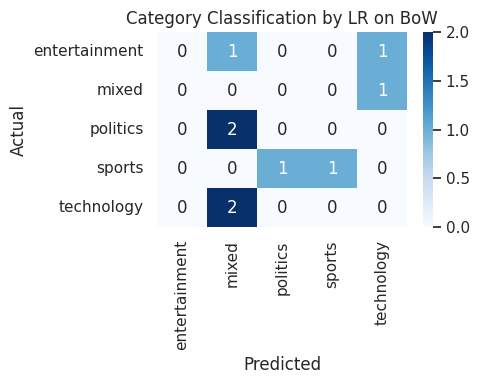

Category Classification by LR on TF-IDF
Accuracy: 0.11
               precision    recall  f1-score   support

entertainment       0.00      0.00      0.00         2
        mixed       0.11      1.00      0.20         1
     politics       0.00      0.00      0.00         2
       sports       0.00      0.00      0.00         2
   technology       0.00      0.00      0.00         2

     accuracy                           0.11         9
    macro avg       0.02      0.20      0.04         9
 weighted avg       0.01      0.11      0.02         9



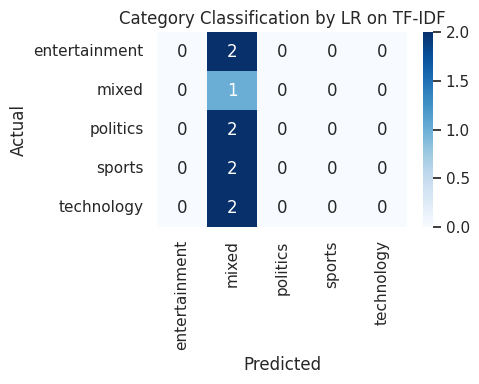

Sentiment Classification by NB on BoW
Accuracy: 0.78
              precision    recall  f1-score   support

    negative       0.67      1.00      0.80         4
    positive       1.00      0.60      0.75         5

    accuracy                           0.78         9
   macro avg       0.83      0.80      0.78         9
weighted avg       0.85      0.78      0.77         9



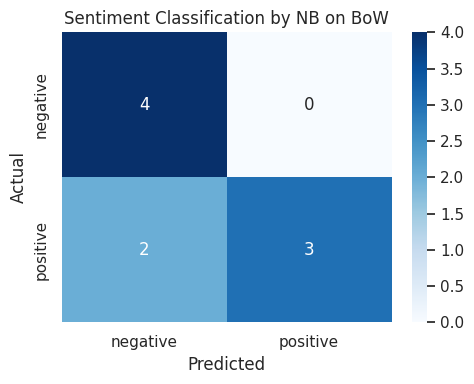

Sentiment Classification by NB on TF-IDF
Accuracy: 0.56
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         4
    positive       0.56      1.00      0.71         5

    accuracy                           0.56         9
   macro avg       0.28      0.50      0.36         9
weighted avg       0.31      0.56      0.40         9



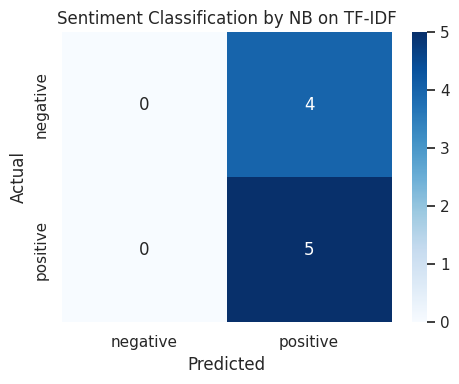

,title,accuracy
2,Sentiment Classification by NB on BoW,0.777778
3,Sentiment Classification by NB on TF-IDF,0.555556
1,Category Classification by LR on TF-IDF,0.111111
0,Category Classification by LR on BoW,0.111111


In [11]:
experiments = []
#category classification on BOW feature
experiments.append(evaluate_classifier(
    LogisticRegression(max_iter=1000), X_bow, df["category"],
    "Category Classification by LR on BoW"
))
#category classification on tfidf feature
experiments.append(evaluate_classifier(
    LogisticRegression(max_iter=1000), X_tfidf, df["category"],
    "Category Classification by LR on TF-IDF"
))

#sentiment classification on BOW feature
experiments.append(evaluate_classifier(
    MultinomialNB(), X_bow, df["sentiment"],
    "Sentiment Classification by NB on BoW"
))
#sentiment classification on tfidf feature
experiments.append(evaluate_classifier(
    MultinomialNB(), X_tfidf, df["sentiment"],
    "Sentiment Classification by NB on TF-IDF"
))


pd.DataFrame(experiments).sort_values("accuracy", ascending=False)

##Unsupervised Learning

In **unsupervised learning**, the model does not receive the answer labels during training.

We ask exploratory questions:

- Do documents naturally cluster by category?
- Do positive and negative documents separate naturally?
- Which categories look most similar?


### Helper function: USL

In [18]:
def dense_array(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)


def plot_pca_projection(X, labels, title):
    X_dense = dense_array(X)
    points = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_dense)
    plot_df = pd.DataFrame({"x": points[:, 0], "y": points[:, 1], "label": labels})
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x="x", y="y", hue="label", s=90)
    for i, row in plot_df.iterrows():
        plt.text(row["x"] + 0.01, row["y"] + 0.01, str(i), fontsize=8)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def run_kmeans_and_compare(X, label_column, title, k=5):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    clusters = km.fit_predict(X)
    comparison = pd.crosstab(pd.Series(clusters, name="cluster"), df[label_column])
    print(title)
    display(comparison)
    plot_pca_projection(X, clusters, title + " - PCA View")
    return clusters




## Model Used:USL
### k-means clustering

**k-means** groups documents around cluster centers called centroids. You choose `k`, the number of clusters.

### Hierarchical clustering

**Hierarchical clustering** builds a tree of similarity. A dendrogram lets us inspect which documents merge first.


k-means on TF-IDF compared with category


category,entertainment,mixed,politics,sports,technology
cluster,,,,,
0,2,2,4,2,4
1,0,1,1,0,0
2,1,0,0,1,0
3,1,1,0,1,0
4,1,1,0,1,1


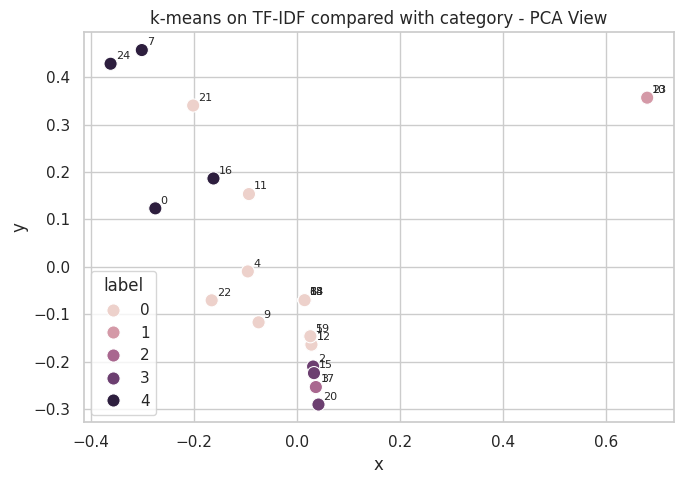

k-means on BoW compared with category


category,entertainment,mixed,politics,sports,technology
cluster,,,,,
0,0,0,0,2,0
1,1,1,0,0,0
2,4,1,4,3,4
3,0,1,1,0,0
4,0,2,0,0,1


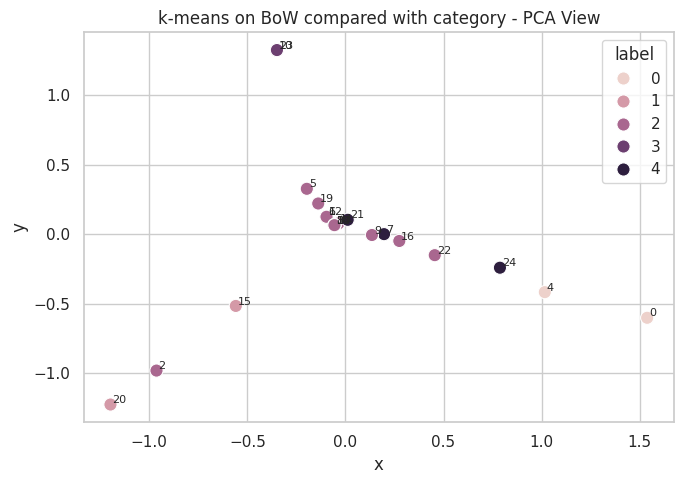

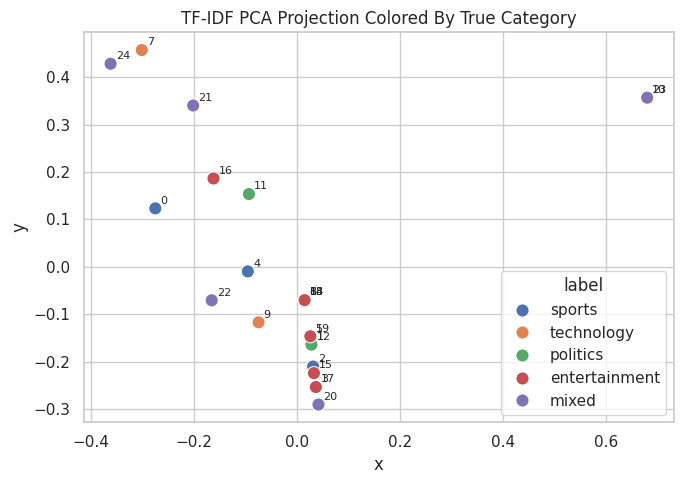

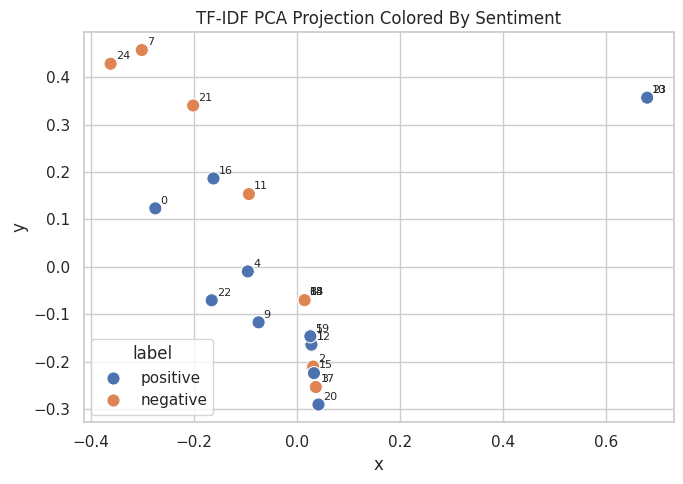

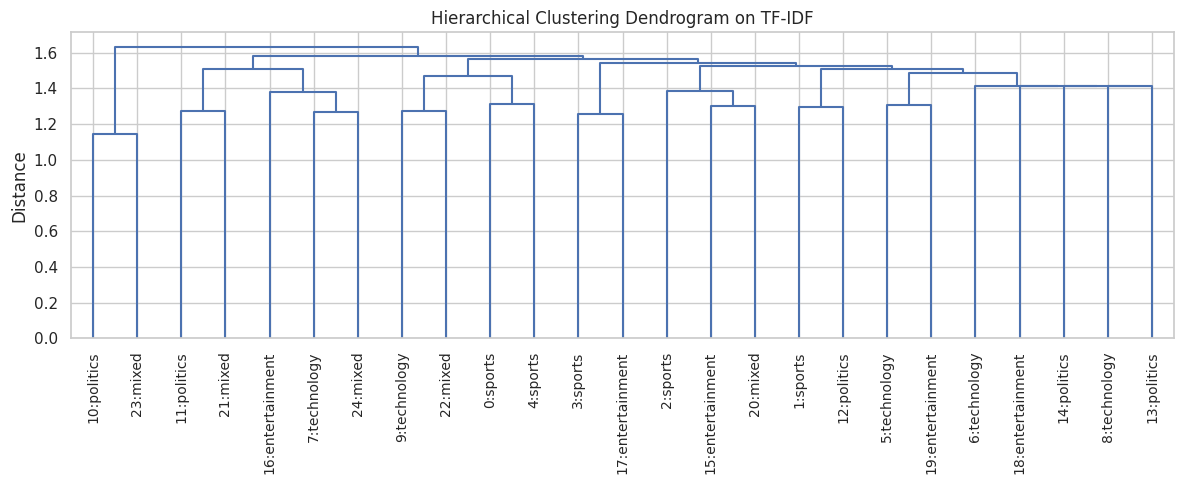

category,entertainment,mixed,politics,sports,technology
hier_cluster,,,,,
0,3,1,3,2,3
1,0,1,0,2,1
2,1,2,1,0,1
3,0,1,1,0,0
4,1,0,0,1,0


In [19]:
tfidf_clusters = run_kmeans_and_compare(X_tfidf, "category", "k-means on TF-IDF compared with category")
bow_clusters = run_kmeans_and_compare(X_bow, "category", "k-means on BoW compared with category")

plot_pca_projection(X_tfidf, df["category"], "TF-IDF PCA Projection Colored By True Category")
plot_pca_projection(X_tfidf, df["sentiment"], "TF-IDF PCA Projection Colored By Sentiment")

linked = linkage(dense_array(X_tfidf), method="ward")
plt.figure(figsize=(12, 5))
dendrogram(linked, labels=[f"{i}:{cat}" for i, cat in enumerate(df["category"])], leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram on TF-IDF")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

agg = AgglomerativeClustering(n_clusters=5)
df["hier_cluster"] = agg.fit_predict(dense_array(X_tfidf))
pd.crosstab(df["hier_cluster"], df["category"])